# AES 클럭글리치 검증 (STM32F4) — 랜덤 파라미터 탐색

기존 `fault201/Lab 1_1B - AES Loop Skip Fault Attack` + CW `GlitchController` 랜덤 탐색을 STM32F4 기준으로 재구성.

**목적:** 알려진-정상 예제(AES)로 이 리그(Husky+CW308+STM32F4, HSE 직결 7.37MHz)에서 **클럭글리치가 결함을 유발하는지** 확인.
- 성공 = 글리치로 AES가 **틀린 *유효* 암호문**(gold_ct와 다름)을 냄.
- **순차 스윕 대신 3D 파라미터(width·offset·ext_offset·repeat) 랜덤 샘플링** → 명중률↑.
- 진단: `reset`이 계속 0이면 글리치가 타겟에 **미도달**(CW308 클럭/점퍼 문제), `reset>0`면 도달하는 것.

**순서:** 셀 위에서부터 실행.

In [1]:
# ===== 1) 셋업 (단독 실행: 스코프 연결 + 클럭 + 헬퍼) =====
%matplotlib inline
SCOPETYPE='OPENADC'; PLATFORM='CW308_STM32F4'; CRYPTO_TARGET='TINYAES128C'; SS_VER='SS_VER_2_1'
import chipwhisperer as cw
import time, struct, logging, random
import matplotlib.pyplot as plt
try:
    scope
except NameError:
    scope = cw.scope(name='Husky')
%run "../../Setup_Scripts/Setup_Generic.ipynb"          # target / prog / reset_target

scope.clock.clkgen_freq = 7.37e6
scope.clock.adc_mul = 1                                  # ADC 1샘플 ≈ 타겟 1사이클 ≈ ext_offset 1
scope.io.hs2 = 'clkgen'
time.sleep(0.2)

def reboot_flush():
    scope.io.nrst = False; time.sleep(0.05); scope.io.nrst = 'high_z'; time.sleep(0.05); target.flush()

print('clkgen_freq =', scope.clock.clkgen_freq, '| is_husky =', scope._is_husky)

INFO: Found ChipWhisperer😍
scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.clock.adc_rate                     changed from 0.0                       to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2                             changed from None                      to clkgen            

(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:704) Target clock may drop; you may need to reset your target.


clkgen_freq = 7371428.571428572 | is_husky = True


In [2]:
%%bash -s "$PLATFORM" "$SS_VER"
# ===== 2) simpleserial-aes 빌드 (STM32F4, TINYAES128C) =====
cd ../../../firmware/mcu/simpleserial-aes
make PLATFORM=$1 CRYPTO_TARGET=TINYAES128C SS_VER=$2 -j 2>&1 | tail -5

+--------------------------------------------------------
+ Built for platform CW308T: STM32F4 Target with:
+ CRYPTO_TARGET = TINYAES128C
+ CRYPTO_OPTIONS = AES128C
+--------------------------------------------------------


Detected known STMF32: STM32F40xxx/41xxx
Extended erase (0x44), this can take ten seconds or more
Attempting to program 5743 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 5743 bytes
gold_ct = c6a13b37878f5b826f4f8162a1c8d879
AES window WIN = 7671 cycles | timeout? False | samples = 8154


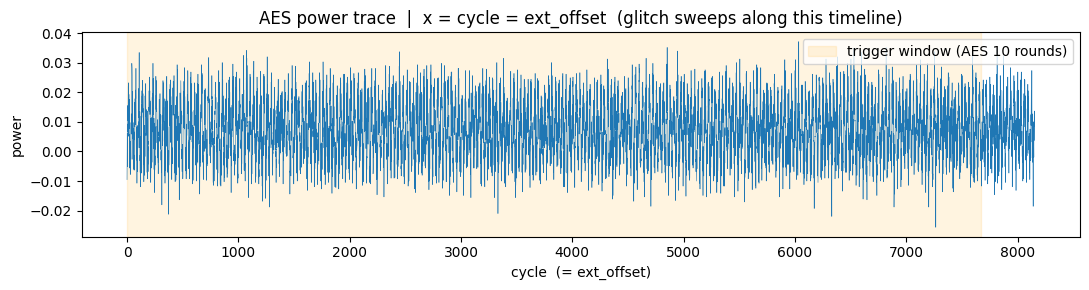

In [3]:
# ===== 3) 플래시 + 키 + gold_ct + 윈도우측정 + AES 파형 =====
fw = "../../../firmware/mcu/simpleserial-aes/simpleserial-aes-{}.hex".format(PLATFORM)
cw.program_target(scope, prog, fw)
if SS_VER == 'SS_VER_2_1': target.reset_comms()
reboot_flush()

KEY = bytearray(range(16)); PT = bytearray([0]*16)
def ensure_key():
    target.simpleserial_write('k', KEY)
    if target.simpleserial_wait_ack() is None:
        reboot_flush(); target.simpleserial_write('k', KEY); target.simpleserial_wait_ack()
ensure_key()

scope.adc.basic_mode = 'rising_edge'
try: scope.trigger.triggers = 'tio4'
except Exception: pass
scope.adc.timeout = 2
scope.arm(); target.simpleserial_write('p', PT)
to = scope.capture(); WIN = int(scope.adc.trig_count)
gold = target.simpleserial_read_witherrors('r', 16, glitch_timeout=1)['payload']

scope.adc.samples = int(min(max(WIN, 1000) * 1.05 + 100, 24000))
scope.arm(); target.simpleserial_write('p', PT); scope.capture()
target.simpleserial_read_witherrors('r', 16, glitch_timeout=1)
wave = scope.get_last_trace()
print('gold_ct =', bytes(gold).hex())
print('AES window WIN =', WIN, 'cycles | timeout?', to, '| samples =', scope.adc.samples)

plt.figure(figsize=(11, 3)); plt.plot(wave, lw=0.4)
plt.axvspan(0, min(WIN, len(wave)), color='orange', alpha=0.12, label='trigger window (AES 10 rounds)')
plt.title('AES power trace  |  x = cycle = ext_offset  (glitch sweeps along this timeline)')
plt.xlabel('cycle  (= ext_offset)'); plt.ylabel('power'); plt.legend(loc='upper right')
plt.tight_layout(); plt.show()

In [4]:
# ===== 4) 클럭글리치 설정 (Husky) + 전환 후 리셋 =====
if scope._is_husky: scope.glitch.enabled = True
scope.glitch.clk_src = 'pll' if scope._is_husky else 'clkgen'
scope.glitch.output = 'clock_xor'
scope.glitch.trigger_src = 'ext_single'
scope.glitch.repeat = 1
scope.io.hs2 = 'glitch'
time.sleep(0.2); reboot_flush(); ensure_key()          # 클럭 전환 후 리셋 + 키 재설정
print(scope.glitch)

enabled           = True
num_glitches      = 1
clk_src           = pll
mmcm_locked       = True
width             = 0
offset            = 0
trigger_src       = ext_single
arm_timing        = after_scope
ext_offset        = 0
repeat            = 1
output            = clock_xor
phase_shift_steps = 4592



랜덤 탐색  N=3000  width(30, 75)  offset(-15, 15)  ext(0, 8054)


random glitch:   0%|          | 0/3000 [00:00<?, ?it/s]

★ FAULTY  ext=3881(48%)  w=71 o=0 rep=1  ct=bd072954a278daf0e9488fc4818e7676
★ FAULTY  ext=3398(42%)  w=48 o=2 rep=1  ct=cf3b4676f86798ea3345ec02c8af15d0
★ FAULTY  ext=5922(74%)  w=48 o=13 rep=2  ct=dd18f45ce70f21eb4f7cb44f7ae5c059
★ FAULTY  ext=4390(55%)  w=56 o=15 rep=1  ct=be6425fc9d2bb9872c61017f23e15c8a
★ FAULTY  ext=2353(29%)  w=67 o=12 rep=2  ct=97ea1005d1d7fc869ec420417902101b
★ FAULTY  ext=95(1%)  w=56 o=11 rep=2  ct=23e5e2f45f235e3538b736dee2a67f85
★ FAULTY  ext=2852(35%)  w=42 o=-3 rep=2  ct=dc6e3def33ff383d3772449dcd339105


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:731) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 13
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:731) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 12


★ FAULTY  ext=2247(28%)  w=31 o=3 rep=2  ct=570101508be4469f1883341d556f30e6
결함 8개 확보 — 종료
DONE: {'normal': 77, 'faulty': 8, 'reset': 5} | faulty: [(3881, 71, 0, 1, 'bd072954a278daf0e9488fc4818e7676'), (3398, 48, 2, 1, 'cf3b4676f86798ea3345ec02c8af15d0'), (5922, 48, 13, 2, 'dd18f45ce70f21eb4f7cb44f7ae5c059'), (4390, 56, 15, 1, 'be6425fc9d2bb9872c61017f23e15c8a'), (2353, 67, 12, 2, '97ea1005d1d7fc869ec420417902101b'), (95, 56, 11, 2, '23e5e2f45f235e3538b736dee2a67f85'), (2852, 42, -3, 2, 'dc6e3def33ff383d3772449dcd339105'), (2247, 31, 3, 2, '570101508be4469f1883341d556f30e6')]

✅ 결함 성공! 대표 (ext_offset, width, offset, repeat): (3881, 71, 0, 1)
   → 이 스케일을 HAETAE EXP7에 적용.


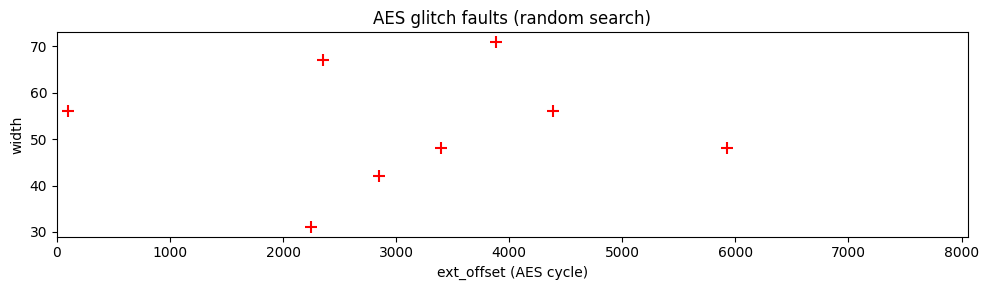

In [5]:
# ===== 5) 랜덤 글리치 탐색 (CW GlitchController random 방식) =====
# 순차 스윕은 '맞는 ext_offset'에 '틀린 width'가 걸리면 놓침 → 3D 파라미터를 매번 랜덤 샘플링.
from tqdm.notebook import trange
logging.getLogger('ChipWhisperer').setLevel(logging.ERROR)
scope.adc.timeout = 0.3
scope.adc.samples = 500                       # 스윕은 빠르게

N_TRIES    = 3000                             # 랜덤 시도 횟수 (원하면↑)
W_RANGE    = (30, 75)                         # width — 이 타겟의 실측 sweet spot ~50 (1~12는 너무 작았음!)
O_RANGE    = (-15, 15)                        # offset (phase)
E_RANGE    = (0, int(WIN * 1.05) if WIN > 0 else 5000)   # ext_offset = AES 윈도우 전체
REP_POOL   = [1, 1, 2]                         # repeat: 대부분 1, 가끔 2
STOP_AFTER = 8                                # 결함 N개 모으면 종료

cnt = {'normal':0, 'faulty':0, 'reset':0}; faulty = []; ensure_key()
print('랜덤 탐색  N=%d  width%s  offset%s  ext%s' % (N_TRIES, W_RANGE, O_RANGE, E_RANGE), flush=True)
bar = trange(N_TRIES, desc='random glitch')
for i in bar:
    w = random.randint(*W_RANGE); o = random.randint(*O_RANGE)
    e = random.randint(*E_RANGE); rep = random.choice(REP_POOL)
    scope.glitch.width = int(w); scope.glitch.offset = int(o)
    scope.glitch.ext_offset = int(e); scope.glitch.repeat = int(rep)
    scope.arm(); target.simpleserial_write('p', PT)
    if scope.capture():                                        # timeout/크래시
        cnt['reset'] += 1; reboot_flush(); ensure_key()
    else:
        out = target.simpleserial_read_witherrors('r', 16, glitch_timeout=1)
        if (not out['valid']) or out['payload'] is None:
            cnt['reset'] += 1; reboot_flush(); ensure_key()
        elif bytes(out['payload']) != bytes(gold):
            ct = bytes(out['payload']); cnt['faulty'] += 1
            faulty.append((int(e), int(w), int(o), int(rep), ct.hex()))
            bar.write('★ FAULTY  ext=%d(%.0f%%)  w=%d o=%d rep=%d  ct=%s'
                      % (e, 100*e/max(E_RANGE[1],1), w, o, rep, ct.hex()))
        else:
            cnt['normal'] += 1
    if i % 10 == 0:
        bar.set_postfix(last='w%d o%d e%d' % (w, o, e), **cnt)
    if cnt['faulty'] >= STOP_AFTER:
        bar.write('결함 %d개 확보 — 종료' % cnt['faulty']); break
scope.glitch.repeat = 1
print('DONE:', cnt, '| faulty:', faulty[:8])

# --- 진단 + 결함 분포 맵 ---
if cnt['reset'] == 0 and cnt['faulty'] == 0:
    print('\n⚠ reset=0, faulty=0 → 글리치가 타겟에 *무효*. CW308 클럭 라우팅/크리스털/A-B 점퍼 점검 필요.')
elif faulty:
    print('\n✅ 결함 성공! 대표 (ext_offset, width, offset, repeat):', faulty[0][:4])
    print('   → 이 스케일을 HAETAE EXP7에 적용.')
    xs=[f[0] for f in faulty]; ys=[f[1] for f in faulty]
    plt.figure(figsize=(10,3)); plt.scatter(xs, ys, c='red', marker='+', s=80)
    plt.xlim(0, E_RANGE[1]); plt.xlabel('ext_offset (AES cycle)'); plt.ylabel('width')
    plt.title('AES glitch faults (random search)'); plt.tight_layout(); plt.show()
else:
    print('\n△ reset은 있으나 clean 결함 없음 → 글리치는 도달함. W_RANGE를 (1,6)로 낮춰 재시도 또는 전압글리치 고려.')

## 해석

- **★ FAULTY 나옴 + 분포 맵**: 이 리그에서 **클럭글리치 정상 동작**. 성공 `(ext_offset, width, offset, repeat)` 스케일을 HAETAE EXP7에 적용.
  진행바 postfix의 `last=`가 마지막 시도 파라미터, FAULTY 로그의 `ext=…%`가 AES 윈도우 내 위치(셀 3 파형과 대응).
- **`reset=0, faulty=0` (글리치 무효)**: 글리치가 코어에 안 닿음 → **CW308 설정 점검** (아래).
- **`reset>0, faulty=0`**: 글리치는 닿지만 clean 스킵이 안 됨 → `W_RANGE=(1,6)`로 낮춰 재시도, 그래도 안 되면 전압글리치.

### CW308 / 소켓보드 점검 (글리치 무효일 때)
- 타겟 클럭 = **CW HS2(외부)**, **온보드 크리스털 OFF** (HSE_BYPASS 펌웨어라 CW 클럭이 OSC_IN에 들어가야 함).
- **A/B 점퍼**: 사용 중인 CW308T-STM32F 소켓보드에서 **F405/F415에 맞는 위치**인지, 클럭이 CW로 라우팅되는지 확인(NewAE 문서).

### 랜덤 탐색 파라미터 조정
- 결함이 안 나오면: `N_TRIES`↑(예: 20000), `W_RANGE`/`O_RANGE` 확대. `reset`이 늘면 도달하는 것이니 width를 낮춰 clean 결함을 노림.

### (선택) 키 복원 — 아래 셀에서 자동 수행 (Lab 1_1B 방식)

## 6) (선택) AES 키 복원 — Lab 1_1B DFA (라운드 축약)

글리치가 **라운드 루프를 초반에 스킵**시키면 암호문이 `ShiftRows(SubBytes(pt ⊕ key))` 형태로 축약된다.
평문 3개(전부 0 / 전부 1 / 전부 2)로 결함 암호문을 얻어 다음으로 마지막(=초기) 라운드 키를 복원:
`sbox[i⊕pt0]⊕sbox[i⊕pt1] == ct0⊕ct1` (그리고 pt2로 교차검증) → ShiftRows 역순 정렬.
- 실제 키를 알고 있으므로(`KEY=00,01,…,0f`) 복원 결과를 **자동 검증**한다.
- 이 복원은 *라운드 축약* 결함이 나는 ext_offset에서만 성립(모든 결함이 그렇지는 않음) → ext를 스캔하며 맞는 지점을 찾는다.

In [6]:
# ===== 6) AES 키 복원 (라운드 축약 DFA, 자동 검증) =====
from tqdm.notebook import trange
sbox = [
0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16]
SR = [0,13,10,7,4,1,14,11,8,5,2,15,12,9,6,3]
KNOWN = bytes(range(16))
scope.adc.timeout = 0.3; scope.adc.samples = 500

def glitch_ct(pt, w, o, rep, ext, tries=60):
    scope.glitch.width=int(w); scope.glitch.offset=int(o)
    scope.glitch.repeat=int(rep); scope.glitch.ext_offset=int(ext)
    for _ in range(tries):
        scope.arm(); target.simpleserial_write('p', bytearray(pt))
        if scope.capture(): reboot_flush(); ensure_key(); continue
        out = target.simpleserial_read_witherrors('r',16,glitch_timeout=1)
        if (not out['valid']) or out['payload'] is None: reboot_flush(); ensure_key(); continue
        ct = bytes(out['payload'])
        if ct != bytes(gold): return ct
    return None

def try_recover(ext, w=50, o=0, rep=1):
    c0 = glitch_ct([0]*16, w,o,rep,ext); c1 = glitch_ct([1]*16, w,o,rep,ext); c2 = glitch_ct([2]*16, w,o,rep,ext)
    if not (c0 and c1 and c2): return None
    kg = []
    for kb in range(16):
        hit = None
        for i in range(256):
            if (sbox[i^0]^sbox[i^1]) == (c0[kb]^c1[kb]) and (sbox[i^0]^sbox[i^2]) == (c0[kb]^c2[kb]):
                hit = i; break
        if hit is None: return None
        kg.append(hit)
    return bytes(kg[SR[i]] for i in range(16))

# 라운드 축약이 일어나는 ext_offset 탐색 (초반 라운드 구간). 실제 키와 일치하면 성공.
W, O, REP = 50, 0, 1
rec = None
for ext in trange(0, int(WIN*0.6), 1, desc='key-recovery ext scan'):
    k = try_recover(ext, W, O, REP)
    if k is not None:
        ok = (k == KNOWN)
        print('ext=%d  recovered=%s  %s' % (ext, k.hex(), 'OK ✅' if ok else '(불일치)'), flush=True)
        if ok: rec = (ext, k); break
if rec:
    print('\n✅ AES 키 복원 성공!  key =', rec[1].hex(), '(=00..0f) | ext_offset =', rec[0], '| width =', W)
else:
    print('\n△ 라운드축약 지점 미발견 — W(40~60)·ext 범위 조정 또는 offset 스윕. (단일바이트 결함은 마지막-라운드 DFA 별도 필요)')

key-recovery ext scan:   0%|          | 0/4602 [00:00<?, ?it/s]

KeyboardInterrupt: 